In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd


meta = pd.read_csv('/content/HAM10000_metadata.csv')
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [ ]:
meta.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
import tensorflow as tf # Imports tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization,Embedding
from tensorflow.keras.layers import Conv2D, MaxPooling2D, ReLU, LSTM,Bidirectional,Attention,Concatenate
from tensorflow.keras import regularizers, optimizers,losses
from tensorflow.keras.metrics import Recall,Precision,AUC,TruePositives,TrueNegatives,FalseNegatives,FalsePositives, SpecificityAtSensitivity,SensitivityAtSpecificity
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.python.keras.utils import np_utils
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn

from imblearn.over_sampling import RandomOverSampler
import imblearn
#from keras.optimizers import Adam
import matplotlib.pyplot as plt
import time
import os
import sklearn.metrics as m
from glob import glob
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
import skimage.io
import skimage.color
import skimage.filters

In [ ]:
data = pd.read_csv('/content/hmnist_28_28_RGB.csv')
data.head()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173.0,124.0,138.0,183.0,147.0,166.0,185.0,154.0,177.0,2.0
1,25,14,30,68,48,75,123,93,126,158,...,60.0,39.0,55.0,25.0,14.0,28.0,25.0,14.0,27.0,2.0
2,192,138,153,200,145,163,201,142,160,206,...,167.0,129.0,143.0,159.0,124.0,142.0,136.0,104.0,117.0,2.0
3,38,19,30,95,59,72,143,103,119,171,...,44.0,26.0,36.0,25.0,12.0,17.0,25.0,12.0,15.0,2.0
4,158,113,139,194,144,174,215,162,191,225,...,209.0,166.0,185.0,172.0,135.0,149.0,109.0,78.0,92.0,2.0


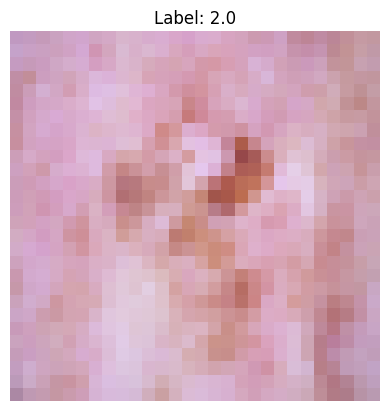

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/hmnist_28_28_RGB.csv')

# Extract label and pixel data
y = df['label'].values
X = df.drop(columns=['label']).values

# Reshape the first image to (28, 28, 3)
img = X[0].reshape(28, 28, 3).astype(np.uint8)

# Plot the image
plt.imshow(img)
plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()


In [ ]:
X = X / 255

print(X[0])
print(X[0].max())
print(X[0].max())

[0.75294118 0.6        0.75686275 ... 0.7254902  0.60392157 0.69411765]
0.9294117647058824
0.9294117647058824


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(3842, 2352)

In [ ]:
# Drop rows with any NaN values from X and y
from sklearn.model_selection import train_test_split

# Remove NaNs from the dataset
df_clean = df.dropna()

# Split into X and y
y = df_clean['label'].values
X = df_clean.drop(columns=['label']).values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.neighbors import NearestNeighbors

# Fit KNN model
KNN = NearestNeighbors(n_neighbors=20).fit(X_train)

# Find 20 nearest neighbors for the first image in the dataset
distances, indices = KNN.kneighbors(X_train[0].reshape(1, -1), n_neighbors=20)

print("Indices of nearest neighbors:\n", indices)


Indices of nearest neighbors:
 [[   0  520 1131 2555 2113  558 1597 2173 3289  466 1681   85 2491  774
   888 1254  436  518 1765  355]]


In [ ]:
indices.shape

(1, 20)

In [ ]:
from scipy.stats import mode

neighbor_labels = y[indices.squeeze()]  # Get neighbor labels
most_common_label = mode(neighbor_labels, keepdims=False).mode

print("Predicted label:", most_common_label)


Predicted label: 2.0


In [ ]:
import pandas as pd

neighbor_labels = y[indices.squeeze()]
most_common_label = pd.Series(neighbor_labels).mode()[0]

print("Predicted label:", most_common_label)


Predicted label: 2.0


In [ ]:
y[indices.squeeze()].mode()

AttributeError: 'numpy.ndarray' object has no attribute 'mode'

In [ ]:
from sklearn.neighbors import NearestNeighbors
from scipy.stats import mode
import numpy as np

# Fit KNN model
KNN = NearestNeighbors(n_neighbors=20).fit(X_train)

# Find 20 nearest neighbors for the first image
distances, indices = KNN.kneighbors(X_train[0].reshape(1, -1), n_neighbors=20)

print("Indices of nearest neighbors:\n", indices)
print("Shape of indices:", indices.shape)

# Get labels of those neighbors
neighbor_labels = y[indices.squeeze()]

# Get most common label (mode)
most_common_label = mode(neighbor_labels, keepdims=False).mode
print("Predicted label:", most_common_label)


Indices of nearest neighbors:
 [[   0  520 1131 2555 2113  558 1597 2173 3289  466 1681   85 2491  774
   888 1254  436  518 1765  355]]
Shape of indices: (1, 20)
Predicted label: 2.0


In [ ]:
nv_indexes = meta.dx[meta.dx == 'nv'].index.tolist()
print((data.label[nv_indexes]))

KeyError: '[1210, 2976, 2977, 2978, 2979, 2980, 2981, 2982, 2983, 2984, 2985, 2986, 2987, 2988, 2989, 2990, 2991, 2992, 2993, 2994, 2995, 2996, 2997, 2998, 2999, 3000, 3001, 3002, 3003, 3004, 3005, 3006, 3007, 3008, 3009, 3010, 3011, 3012, 3013, 3014, 3015, 3016, 3017, 3018, 3019, 3020, 3021, 3022, 3023, 3024, 3025, 3026, 3027, 3028, 3029, 3030, 3031, 3032, 3033, 3034, 3035, 3036, 3037, 3038, 3039, 3040, 3041, 3042, 3043, 3044, 3045, 3046, 3047, 3048, 3049, 3050, 3051, 3052, 3053, 3054, 3055, 3056, 3057, 3058, 3059, 3060, 3061, 3062, 3063, 3064, 3065, 3066, 3067, 3068, 3069, 3070, 3071, 3072, 3073, 3074, 3075, 3076, 3077, 3078, 3079, 3080, 3081, 3082, 3083, 3084, 3085, 3086, 3087, 3088, 3089, 3090, 3091, 3092, 3093, 3094, 3095, 3096, 3097, 3098, 3099, 3100, 3101, 3102, 3103, 3104, 3105, 3106, 3107, 3108, 3109, 3110, 3111, 3112, 3113, 3114, 3115, 3116, 3117, 3118, 3119, 3120, 3121, 3122, 3123, 3124, 3125, 3126, 3127, 3128, 3129, 3130, 3131, 3132, 3133, 3134, 3135, 3136, 3137, 3138, 3139

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import math

knn = KNeighborsClassifier()
search_space = [{'n_neighbors': list(range(1, int(math.sqrt(8012))))}]

In [ ]:
grid_search = GridSearchCV(knn, search_space).fit(X_train, y_train)

In [ ]:
print(grid_search.best_estimator_.get_params()['n_neighbors'])
best_k = grid_search.best_params_['n_neighbors']
print("Best k:", best_k)

7
Best k: 7


In [ ]:
model = grid_search.best_estimator_

In [ ]:
y_pred = model.predict(X_train)

from sklearn import metrics
metrics.accuracy_score(y_train, y_pred)

0.7445977609997396

ValueError: The number of FixedLocator locations (6), usually from a call to set_ticks, does not match the number of labels (7).

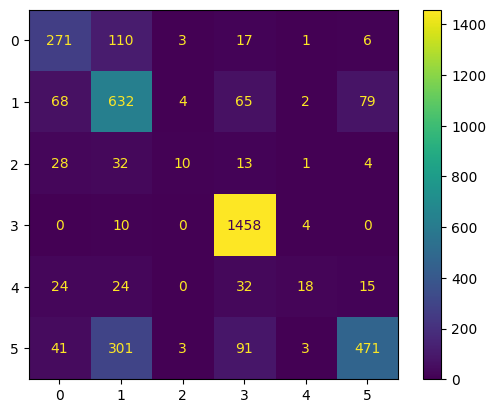

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_train,
    y_train,
    display_labels=list(range(7))
)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import math

knn = KNeighborsClassifier()

search_space = [{'n_neighbors': list(range(1, int(math.sqrt(8012))))}]

grid_search = GridSearchCV(estimator=knn, param_grid=search_space, scoring='accuracy')

grid_search.fit(X_train, y_train)

print(grid_search.best_estimator_.get_params()['n_neighbors'])
best_k = grid_search.best_params_['n_neighbors']
print("Best k:", best_k)

7
Best k: 7


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import itertools
from glob import glob
from PIL import Image

In [ ]:
import numpy as np
print(np.__version__)

2.0.2


In [ ]:
!pip install --upgrade scikit-learn

In [ ]:
!pip install pydub

In [ ]:
#IGNORING WARNINGS
from warnings import filterwarnings
filterwarnings("ignore",category=DeprecationWarning)
filterwarnings("ignore", category=FutureWarning)
filterwarnings("ignore", category=UserWarning)
#GENERAL
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
#PATH PROCESS
import os
import os.path
from pathlib import Path
import glob
#IMAGE PROCESS
from PIL import Image
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from keras.applications.vgg16 import preprocess_input, decode_predictions
import imageio
from IPython.display import Image
import matplotlib.image as mpimg
#MUSIC PROCESS
import pydub
from scipy.io.wavfile import read, write
import librosa
import librosa.display
import IPython
from IPython.display import Audio
import scipy
#SCALER & TRANSFORMATION
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras import regularizers
from sklearn.preprocessing import LabelEncoder
#ACCURACY CONTROL
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
#OPTIMIZER
# from keras.optimizers import Adam,Optimizer,Optimizer, SGD
from tensorflow.keras.optimizers import Adam,Optimizer,Optimizer, SGD
#MODEL LAYERS
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization,MaxPooling2D,BatchNormalization,\
                        Permute, TimeDistributed, Bidirectional,GRU, SimpleRNN,\
LSTM, GlobalAveragePooling2D, SeparableConv2D, ZeroPadding2D, Convolution2D, ZeroPadding2D,Reshape,\
Conv2DTranspose, LeakyReLU, Conv1D, AveragePooling1D, MaxPooling1D
from keras import models
from keras import layers
import tensorflow as tf
from tensorflow.keras.applications import VGG16,VGG19,inception_v3
from keras import backend as K
from tensorflow.keras.utils import plot_model
from tensorflow.keras.datasets import mnist
import keras
#SKLEARN CLASSIFIER
# from xgboost import XGBClassifier, XGBRegressor
# from lightgbm import LGBMClassifier, LGBMRegressor
# from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

In [ ]:
!pip install modAL

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.0/559.0 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.3 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv('/content/hmnist_28_28_RGB.csv')
df.head()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [ ]:
df= df.dropna()

In [ ]:
print(df["label"].value_counts())

label
4    6705
6    1113
2    1099
1     514
0     327
5     142
3     115
Name: count, dtype: int64


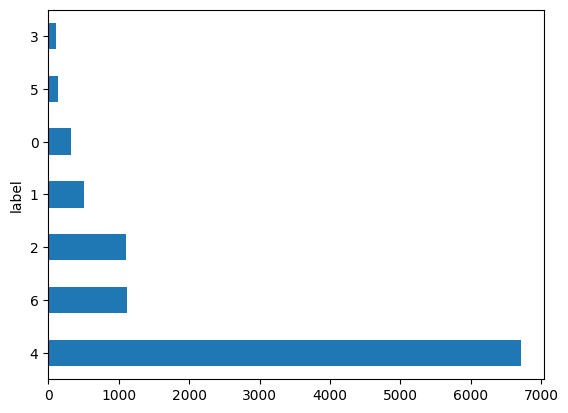

In [ ]:
%matplotlib inline
df["label"].value_counts().plot(kind='barh')
plt.savefig('label_count.pdf', dpi=1)

In [ ]:
encoder_label = OneHotEncoder()
scaler_data = StandardScaler()

In [ ]:
X = df.iloc[:,:-1].values
Y = df["label"].values

In [ ]:
print(X.shape)
print(Y.shape)

(10015, 2352)
(10015,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from collections import Counter

# Separate the data into features and labels
features = df.drop(columns=['label'])
labels = df['label']

# Display original class distribution
print('Original dataset shape %s' % Counter(labels))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Upsample the minority classes using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Downsample the majority class using random under-sampling
majority_class = y_train_resampled.value_counts().idxmax()
minority_classes = y_train_resampled.value_counts().index[y_train_resampled.value_counts() < y_train_resampled.value_counts().max()]

downsampled_X = []
downsampled_y = []

for minority_class in minority_classes:
    X_minority = X_train_resampled[y_train_resampled == minority_class]
    y_minority = y_train_resampled[y_train_resampled == minority_class]

    X_majority = X_train_resampled[y_train_resampled == majority_class]
    y_majority = y_train_resampled[y_train_resampled == majority_class]

    X_downsampled, y_downsampled = resample(X_majority, y_majority, n_samples=X_minority.shape[0], random_state=42)

    downsampled_X.append(X_downsampled)
    downsampled_y.append(y_downsampled)

X_train_resampled = pd.concat([X_train_resampled] + downsampled_X)
y_train_resampled = pd.concat([y_train_resampled] + downsampled_y)

# Create a new DataFrame with resampled data
resampled_data = pd.concat([X_train_resampled, y_train_resampled], axis=1)

# Display the resampled class distribution
print('Resampled dataset shape %s' % Counter(y_train_resampled))

# Save the resampled data to a new CSV file
resampled_data.to_csv('newdata.csv', index=False)

Original dataset shape Counter({4: 6705, 6: 1113, 2: 1099, 1: 514, 0: 327, 5: 142, 3: 115})
Resampled dataset shape Counter({4: 5367, 2: 5367, 0: 5367, 3: 5367, 6: 5367, 1: 5367, 5: 5367})


In [ ]:
data= pd.read_csv("/content/newdata.csv")
print('[data]', data.shape)
data = data.sample(frac=0.01)
print('[data]', data.shape)

[data] (37569, 2353)
[data] (376, 2353)


In [ ]:
print(data["label"].value_counts())

label
3    63
2    57
1    55
4    51
0    51
6    50
5    49
Name: count, dtype: int64


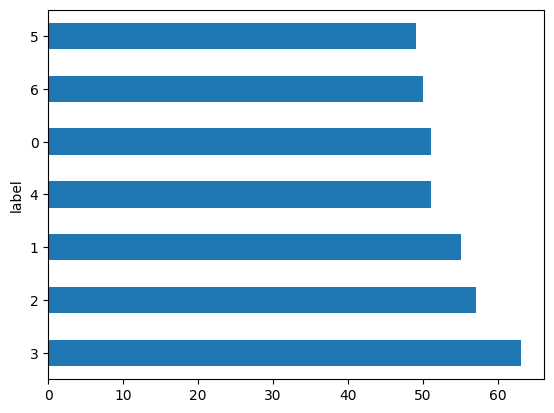

In [ ]:
%matplotlib inline
data["label"].value_counts().plot(kind='barh')
plt.savefig('label_count.pdf', dpi=1)

In [ ]:
X = data.iloc[:,:-1].values
Y = data["label"].values

In [ ]:
print(X.shape)
print(Y.shape)

(376, 2352)
(376,)


In [ ]:
df= df.dropna()

In [ ]:
print(df["label"].value_counts())

label
4    6705
6    1113
2    1099
1     514
0     327
5     142
3     115
Name: count, dtype: int64


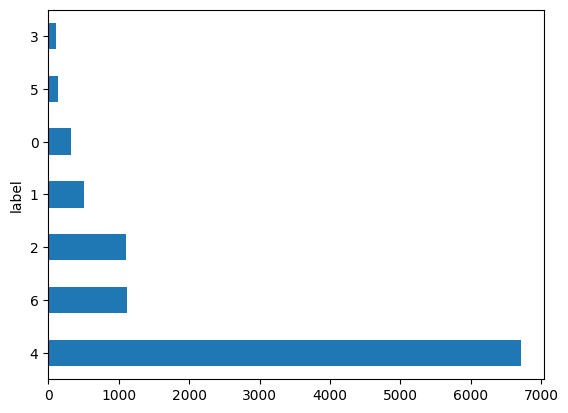

In [ ]:
%matplotlib inline
df["label"].value_counts().plot(kind='barh')
plt.savefig('label_count.pdf', dpi=1)

In [ ]:
encoder_label = OneHotEncoder()
scaler_data = StandardScaler()

In [ ]:
X = df.iloc[:,:-1].values
Y = df["label"].values

In [ ]:
print(X.shape)
print(Y.shape)

(10015, 2352)
(10015,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from collections import Counter

# Separate the data into features and labels
features = df.drop(columns=['label'])
labels = df['label']

# Display original class distribution
print('Original dataset shape %s' % Counter(labels))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Upsample the minority classes using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Downsample the majority class using random under-sampling
majority_class = y_train_resampled.value_counts().idxmax()
minority_classes = y_train_resampled.value_counts().index[y_train_resampled.value_counts() < y_train_resampled.value_counts().max()]

downsampled_X = []
downsampled_y = []

for minority_class in minority_classes:
    X_minority = X_train_resampled[y_train_resampled == minority_class]
    y_minority = y_train_resampled[y_train_resampled == minority_class]

    X_majority = X_train_resampled[y_train_resampled == majority_class]
    y_majority = y_train_resampled[y_train_resampled == majority_class]

    X_downsampled, y_downsampled = resample(X_majority, y_majority, n_samples=X_minority.shape[0], random_state=42)

    downsampled_X.append(X_downsampled)
    downsampled_y.append(y_downsampled)

X_train_resampled = pd.concat([X_train_resampled] + downsampled_X)
y_train_resampled = pd.concat([y_train_resampled] + downsampled_y)

# Create a new DataFrame with resampled data
resampled_data = pd.concat([X_train_resampled, y_train_resampled], axis=1)

# Display the resampled class distribution
print('Resampled dataset shape %s' % Counter(y_train_resampled))

# Save the resampled data to a new CSV file
resampled_data.to_csv('newdata.csv', index=False)


Original dataset shape Counter({4: 6705, 6: 1113, 2: 1099, 1: 514, 0: 327, 5: 142, 3: 115})
Resampled dataset shape Counter({4: 5367, 2: 5367, 0: 5367, 3: 5367, 6: 5367, 1: 5367, 5: 5367})


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 376 entries, 36287 to 7296
Columns: 2353 entries, pixel0000 to label
dtypes: int64(2353)
memory usage: 6.8 MB


In [ ]:
data.describe()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
count,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000,...,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000,376.000000
mean,169.550532,129.848404,137.659574,177.574468,136.819149,144.914894,184.295213,142.808511,151.433511,188.835106,...,175.885638,136.539894,142.648936,168.319149,129.872340,135.752660,160.422872,123.101064,129.010638,2.944149
std,55.567929,45.254432,48.451004,48.872403,40.235099,43.245201,42.027808,35.104956,37.712892,37.091159,...,46.031354,38.807539,41.455700,52.364306,43.725504,46.351124,58.319848,48.126117,50.778682,1.954023
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,...,2.000000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,144.750000,112.000000,116.000000,155.750000,122.000000,125.000000,162.750000,127.000000,133.000000,168.000000,...,155.750000,120.000000,124.000000,147.750000,113.000000,117.000000,135.750000,103.000000,107.500000,1.000000
50%,183.000000,139.000000,148.000000,187.000000,142.000000,152.000000,191.000000,147.000000,156.500000,193.000000,...,187.000000,142.000000,149.000000,183.000000,139.500000,144.000000,177.000000,134.500000,139.000000,3.000000
75%,208.250000,161.000000,170.000000,210.000000,164.000000,173.000000,212.000000,165.000000,174.000000,214.000000,...,206.000000,162.250000,170.000000,204.000000,160.000000,166.250000,202.000000,158.000000,164.250000,5.000000
max,247.000000,217.000000,242.000000,248.000000,220.000000,228.000000,248.000000,222.000000,232.000000,249.000000,...,243.000000,214.000000,227.000000,239.000000,206.000000,223.000000,239.000000,207.000000,228.000000,6.000000


In [ ]:
y = data.label
X = data.drop(columns=['label']).to_numpy()

# Import Data

In [ ]:
!pip install pandas

In [ ]:
import pandas as pd
data = pd.read_csv('/content/hmnist_28_28_RGB.csv')
data

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,183,165,181,182,165,180,184,166,182,188,...,208,185,187,208,186,186,206,187,189,0
10011,2,3,1,38,33,32,121,104,103,132,...,96,79,76,24,23,21,3,4,1,0
10012,132,118,118,167,149,149,175,156,160,184,...,204,181,178,181,159,153,172,151,145,0
10013,160,124,146,164,131,152,167,127,146,169,...,185,162,167,184,157,166,185,162,172,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Columns: 2353 entries, pixel0000 to label
dtypes: int64(2353)
memory usage: 179.8 MB


In [ ]:
data.columns

Index(['pixel0000', 'pixel0001', 'pixel0002', 'pixel0003', 'pixel0004',
       'pixel0005', 'pixel0006', 'pixel0007', 'pixel0008', 'pixel0009',
       ...
       'pixel2343', 'pixel2344', 'pixel2345', 'pixel2346', 'pixel2347',
       'pixel2348', 'pixel2349', 'pixel2350', 'pixel2351', 'label'],
      dtype='object', length=2353)

In [ ]:
data.isnull().any().sum()

np.int64(0)

In [ ]:
y = data['label']
x = data.drop(columns = ['label'])


# Exploratory Data Analysis

In [ ]:
tabular_data = pd.read_csv('/content/HAM10000_metadata.csv')
tabular_data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
classes = {4: ('nv', ' melanocytic nevi'), 6: ('mel', 'melanoma'), 2 :('bkl', 'benign keratosis-like lesions'), 1:('bcc' , ' basal cell carcinoma'), 5: ('vasc', ' pyogenic granulomas and hemorrhage'), 0: ('akiec', 'Actinic keratoses and intraepithelial carcinomae'),  3: ('df', 'dermatofibroma')}
#classes = {'mel':0 ,'vasc':1,'df':2,'nv':3,'bkl':4,'bcc':5,'ak':6}

### Frequency Distribution Of Classes

Text(0.5, 1.0, 'Frequency Distribution of Classes')

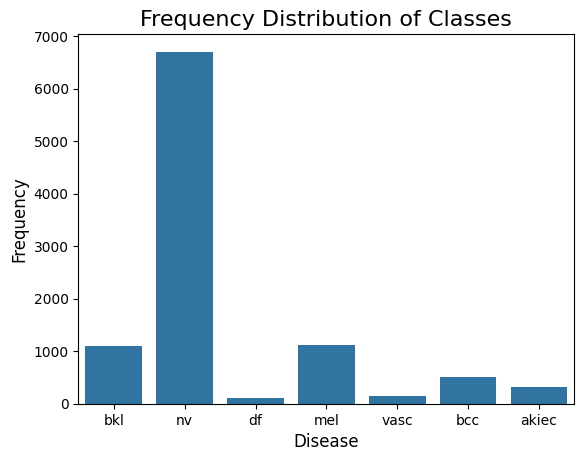

In [ ]:
sns.countplot(x = 'dx', data = tabular_data)
plt.xlabel('Disease', size=12)
plt.ylabel('Frequency', size=12)
plt.title('Frequency Distribution of Classes', size=16)
#it shows imbalance dataset

### Distribution of Disease over Gender

Text(0.5, 1.0, 'Gender of Patient')

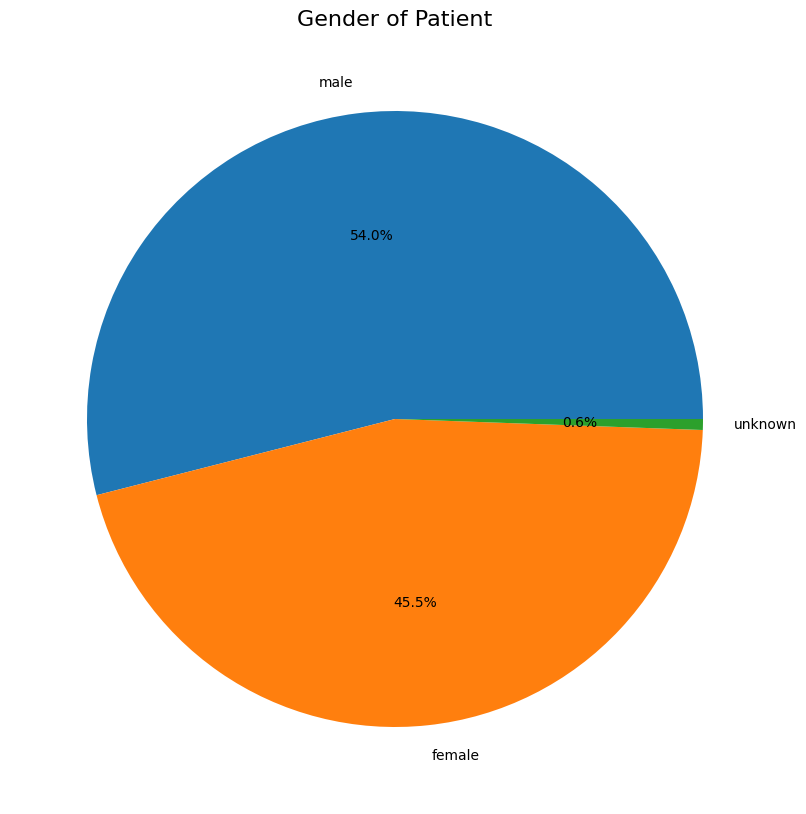

In [ ]:
bar, ax = plt.subplots(figsize = (10,10))
plt.pie(tabular_data['sex'].value_counts(), labels = tabular_data['sex'].value_counts().index, autopct="%.1f%%")
plt.title('Gender of Patient', size=16)

### Histogram of Age of Patients

Text(0.5, 1.0, 'Histogram of Age of Patients')

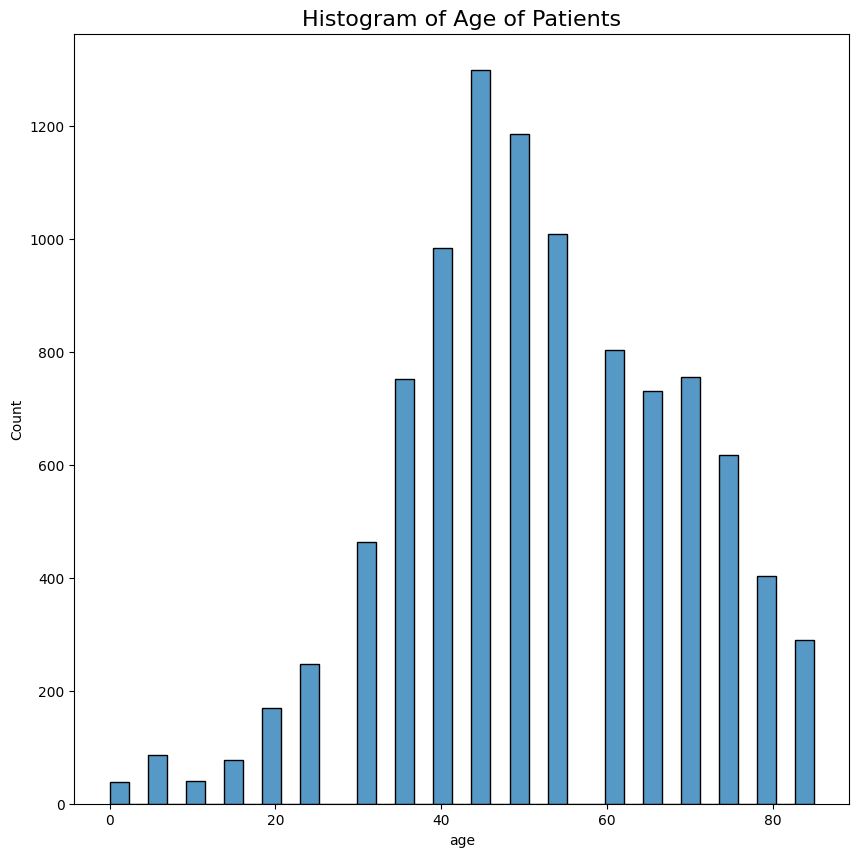

In [ ]:
bar, ax = plt.subplots(figsize=(10,10))
sns.histplot(tabular_data['age'])
plt.title('Histogram of Age of Patients', size=16)

## Location of Disease over Gender

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'back'),
  Text(1, 0, 'lower extremity'),
  Text(2, 0, 'trunk'),
  Text(3, 0, 'upper extremity'),
  Text(4, 0, 'abdomen'),
  Text(5, 0, 'face'),
  Text(6, 0, 'chest'),
  Text(7, 0, 'foot'),
  Text(8, 0, 'scalp'),
  Text(9, 0, 'neck'),
  Text(10, 0, 'unknown'),
  Text(11, 0, 'hand'),
  Text(12, 0, 'genital'),
  Text(13, 0, 'ear'),
  Text(14, 0, 'acral')])

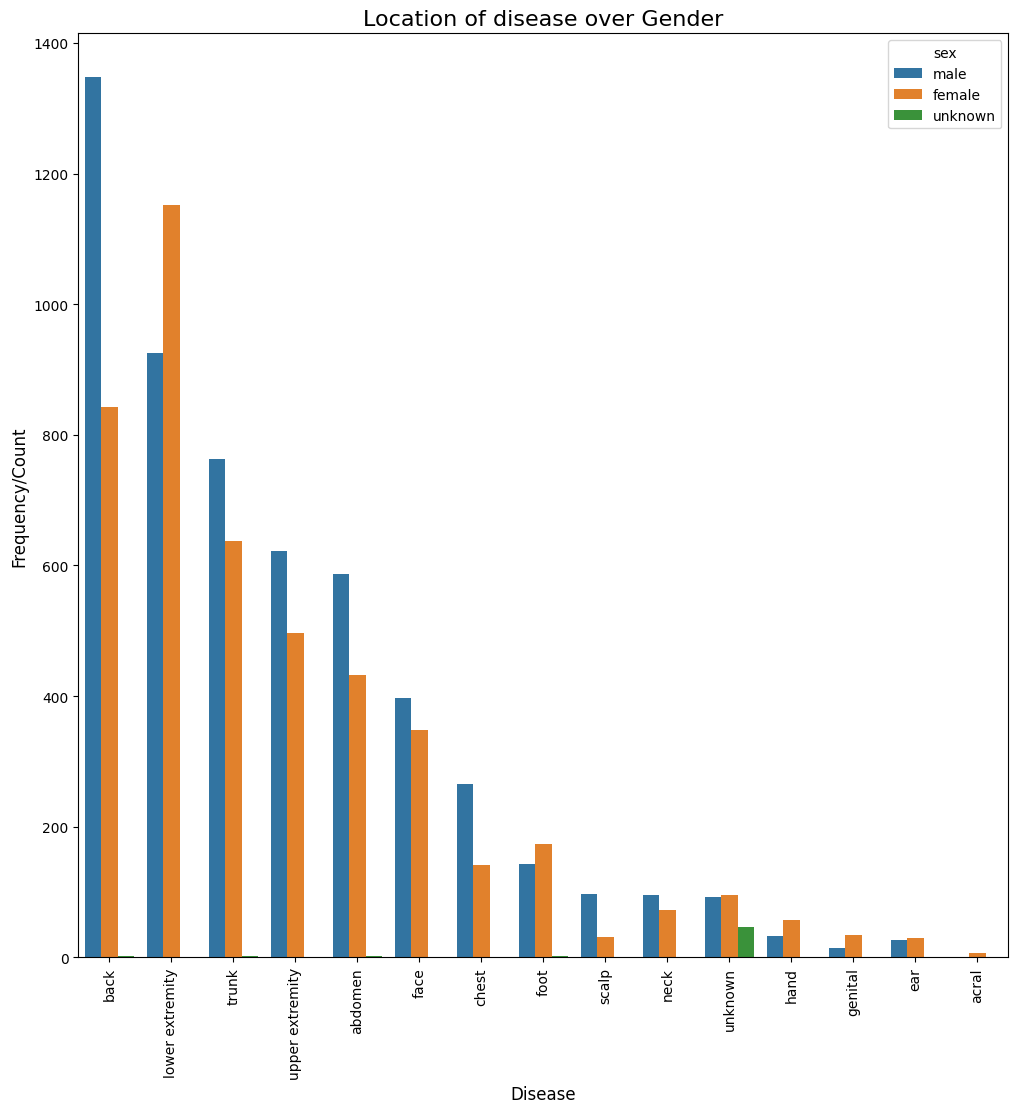

In [ ]:
value = tabular_data[['localization', 'sex']].value_counts().to_frame()
value.reset_index(level=[1,0 ], inplace=True)
temp = value.rename(columns = {'localization':'location', 0: 'count'})

bar, ax = plt.subplots(figsize = (12, 12))
sns.barplot(x = 'location',  y='count', hue = 'sex', data = temp)
plt.title('Location of disease over Gender', size = 16)
plt.xlabel('Disease', size=12)
plt.ylabel('Frequency/Count', size=12)
plt.xticks(rotation = 90)

# Oversampling

In [ ]:
oversample = RandomOverSampler()
x,y  = oversample.fit_resample(x,y)

In [ ]:
x= np.array(x).reshape(-1,28,28,3)
print('Shape of X :',x.shape)

Shape of X : (46935, 28, 28, 3)


In [ ]:
y = to_categorical(y)

In [ ]:
y.shape

(46935, 7)

# Strandardization and Splitting Data

In [ ]:
x = (x-np.mean(x))/np.std(x)

X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size=0.2, random_state=1)

In [ ]:
Y_train.shape

(37548, 7)

# Model Training

In [ ]:
def blockred(inp,filters):
    #Inception
    x = Conv2D(filters, 1, activation="relu",padding='same',use_bias=False)(inp)
    x = layers.MaxPooling2D(2)(x)
    x = BatchNormalization(axis=1)(x)

    #VGG + SQuizenet
    y = Conv2D(filters*2,3,activation="relu", padding='same',use_bias=False,)(inp)
    y = Conv2D(filters,3,activation="relu", padding='same',use_bias=False,)(y)
    y = layers.MaxPooling2D(2)(y)
    y = BatchNormalization(axis=1)(y)
    y = Dropout(0.25)(y)

    #InceptionResnet+Squize
    z = Conv2D(filters*2, 3, activation="relu", padding='same',use_bias=False)(inp)
    z = Conv2D(filters, 1, activation="relu", padding='same',use_bias=False)(inp)
    z = layers.MaxPooling2D(2)(z)
    z = BatchNormalization(axis=1)(z)
    output1 = layers.add([x,y,z])
    return output1

In [ ]:
Name= "CNN0"
inputs = keras.Input(shape=(28,28,3), name="img")
x = layers.Conv2D(32, 3, activation="relu")(inputs)

bl1=blockred(x,32)

bl2=blockred(bl1,64)

bl3=blockred(bl2,64)

# y = Conv2D(filters=128, kernel_size=(5, 5), activation='relu')(bl3)
# y = Conv2D(filters=128, kernel_size=(3, 3), activation='relu')(y)
# y = MaxPooling2D(pool_size=(2, 2))(y)
# y = BatchNormalization(axis=-1)(y)
# y = Dropout(0.25)(y)
y = Flatten()(bl3)
y = Dense(256, activation='relu')(y)
y = Dropout(0.5)(y)
y = Dense(64, activation='relu')(y)
y = Dropout(0.5)(y)
outputs=Dense(7, activation='softmax')(y)
model = keras.Model(inputs, outputs, name=Name)
print(model.summary())

Model: "CNN0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img (InputLayer)    │ (None, 28, 28, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 26, 26,    │        896 │ img[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 26, 26,    │     18,432 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 26, 26,    │     18,432 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 26, 26,    │      1,024 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 13, 13,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 26, 26,    │      1,024 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 13, 13,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │         52 │ max_pooling2d_1[… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 13, 13,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 13, 13,    │         52 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 13, 13,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │         52 │ max_pooling2d_2[… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 13, 13,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ dropout[0][0],    │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 13, 13,    │     36,864 │ add[0][0]         │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 13, 13,    │     73,728 │ conv2d_7[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 13, 13,    │      2,048 │ add[0][0]       

 Total params: 475,023 (1.81 MB)

 Trainable params: 474,891 (1.81 MB)

 Non-trainable params: 132 (528.00 B)

None


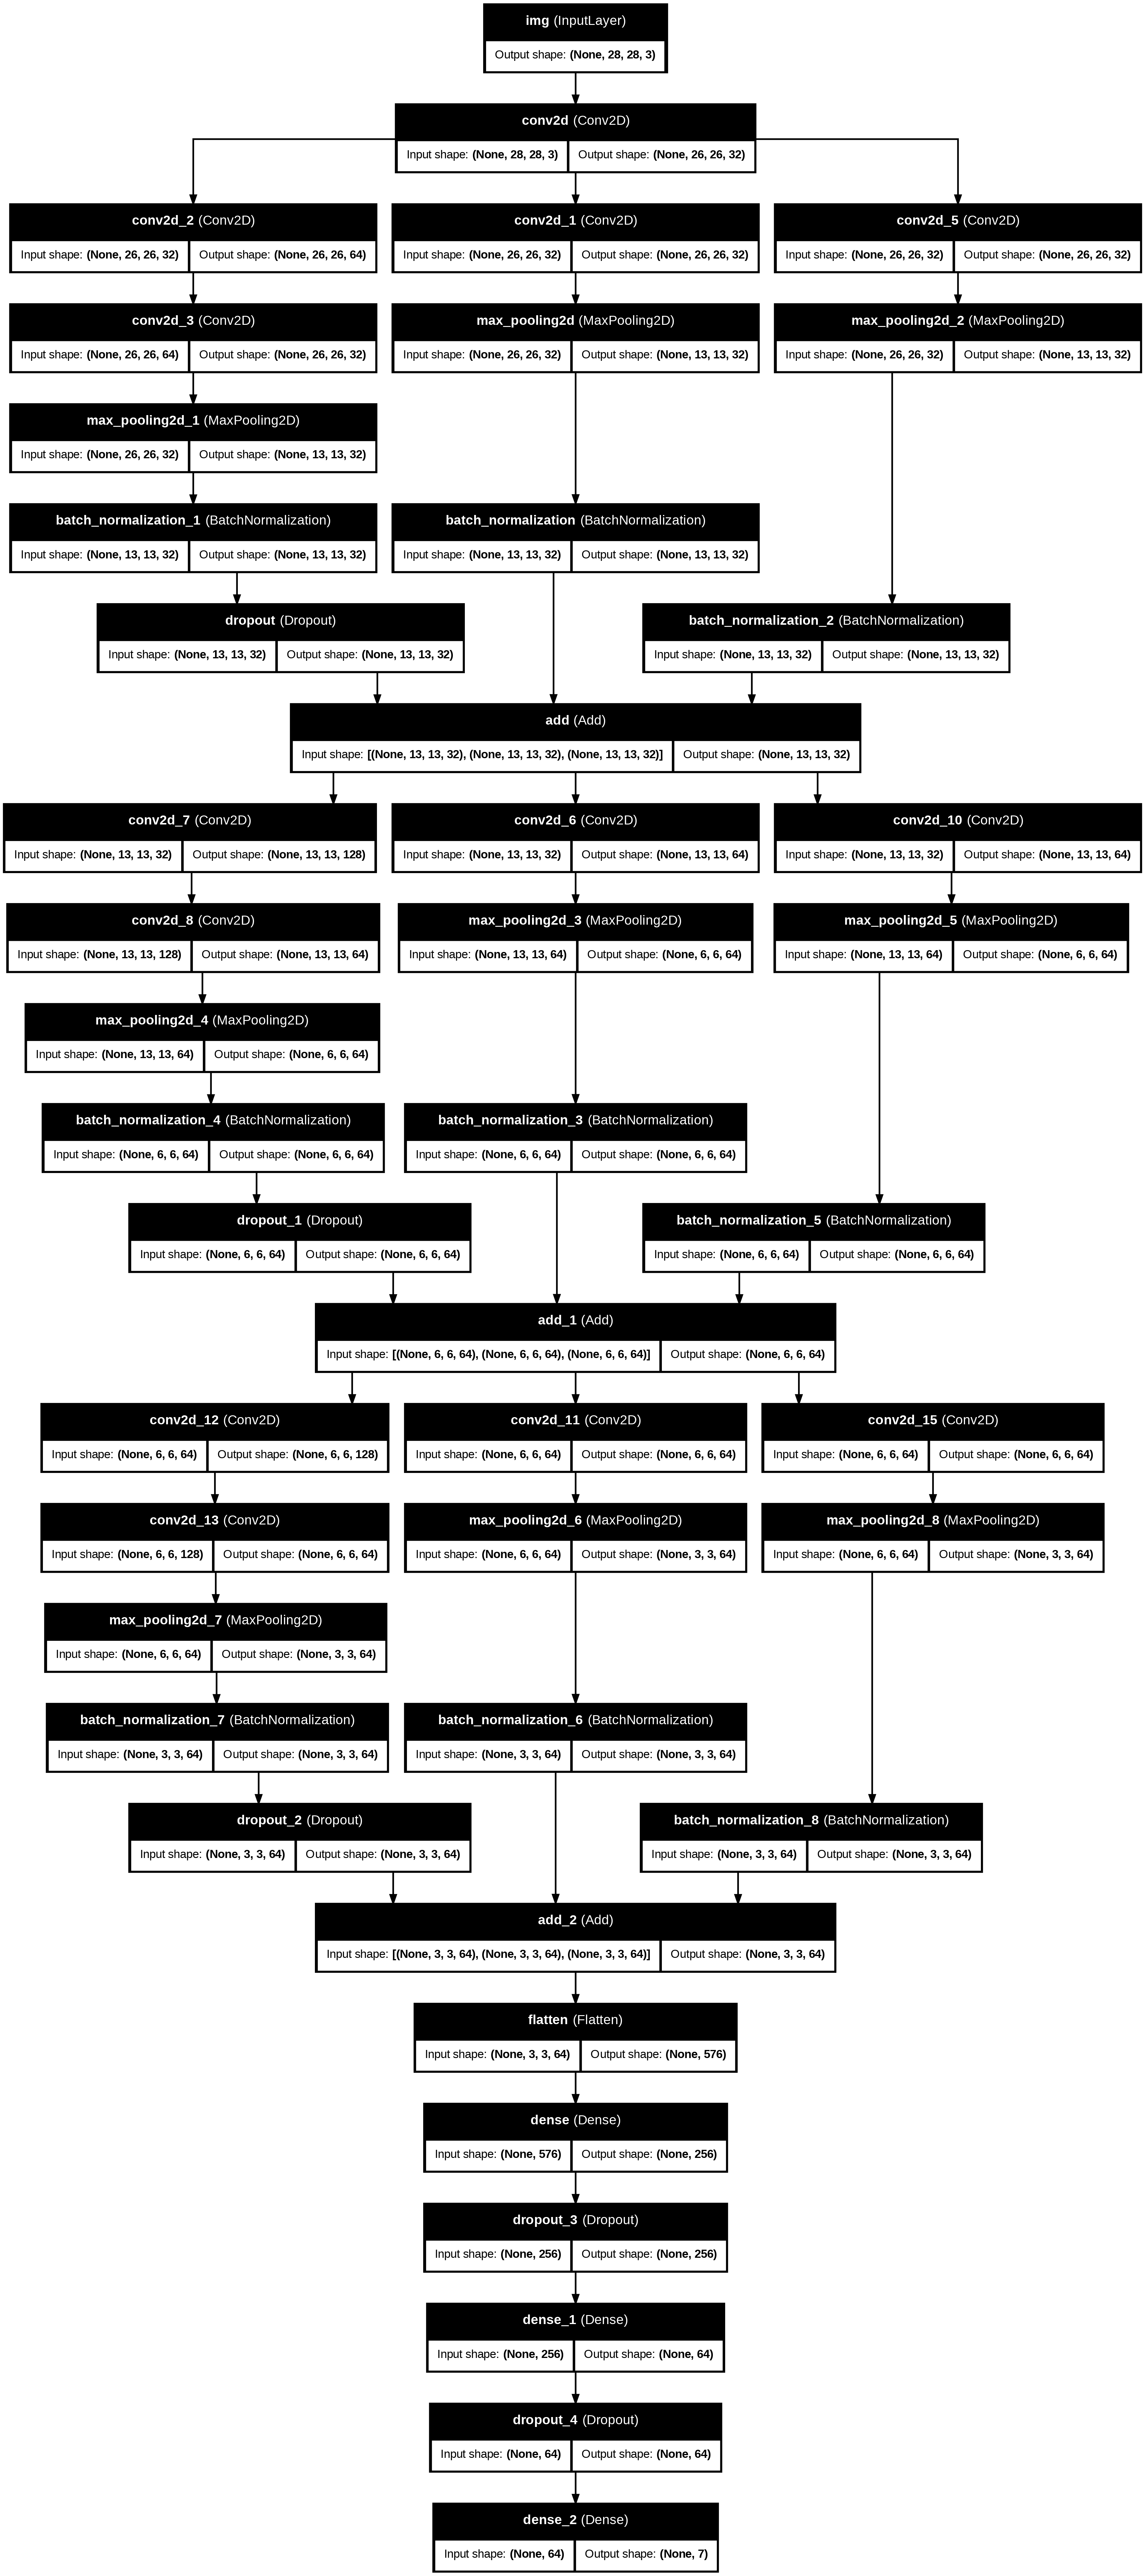

In [ ]:
plot_model(model, to_file=Name+'.png',show_shapes= True , show_layer_names=True)

In [ ]:
callback = tf.keras.callbacks.ModelCheckpoint(filepath='best_model.h5',
                                                  monitor='val_acc', mode='max',
                                                 verbose=1)

In [ ]:
model.compile(optimizer= keras.optimizers.Adam(),
              loss=keras.losses.CategoricalCrossentropy() ,
              metrics=['acc',Recall(),Precision(),AUC(),TruePositives(),TrueNegatives(),FalseNegatives(),FalsePositives()])
history = model.fit(X_train, Y_train, epochs=20, validation_data=(X_test, Y_test), batch_size=128, callbacks=[callback])

Epoch 1/20
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.2721 - auc: 0.6665 - false_negatives: 17120.6738 - false_positives: 1603.8911 - loss: 1.9873 - precision: 0.4225 - recall: 0.0758 - true_negatives: 111674.3984 - true_positives: 1759.0408
Epoch 1: saving model to best_model.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - acc: 0.2724 - auc: 0.6668 - false_negatives: 17172.7188 - false_positives: 1609.2543 - loss: 1.9862 - precision: 0.4231 - recall: 0.0760 - true_negatives: 112048.7266 - true_positives: 1770.2780 - val_acc: 0.3908 - val_auc: 0.7833 - val_false_negatives: 8377.0000 - val_false_positives: 274.0000 - val_loss: 1.5517 - val_precision: 0.7866 - val_recall: 0.1076 - val_true_negatives: 56048.0000 - val_true_positives: 1010.0000
Epoch 2/20
292/294 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.5101 - auc: 0.8636 - false_negatives: 13143.0654 - false_positives: 2026.6747 - loss: 1.2659 - precision: 0.7347 - recall: 0.2889 - true_negatives: 110485.3281 - true_positives: 5608.9351
Epoch 2: saving model to best_model.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - acc: 0.5104 - auc: 0.8637 - false_negatives: 13267.9150 - false_positives: 2049.0779 - loss: 1.2652 - precision: 0.7348 - recall: 0.2892 - true_negatives: 111608.8984 - true_positives: 5675.0815 - val_acc: 0.5300 - val_auc: 0.8805 - val_false_negatives: 6156.0000 - val_false_positives: 1283.0000 - val_loss: 1.1920 - val_precision: 0.7158 - val_recall: 0.3442 - val_true_negatives: 55039.0000 - val_true_positives: 3231.0000
Epoch 3/20
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.6148 - auc: 0.9127 - false_negatives: 10462.2490 - false_positives: 2338.0444 - loss: 1.0226 - precision: 0.7761 - recall: 0.4285 - true_negatives: 110557.9531 - true_positives: 8353.7510
Epoch 3: saving model to best_model.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - acc: 0.6149 - auc: 0.9128 - false_negatives: 10526.1865 - false_positives: 2354.2610 - loss: 1.0222 - precision: 0.7762 - recall: 0.4288 - true_negatives: 111303.7188 - true_positives: 8416.8105 - val_acc: 0.7360 - val_auc: 0.9579 - val_false_negatives: 3989.0000 - val_false_positives: 967.0000 - val_loss: 0.7274 - val_precision: 0.8481 - val_recall: 0.5751 - val_true_negatives: 55355.0000 - val_true_positives: 5398.0000
Epoch 4/20
292/294 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.6999 - auc: 0.9462 - false_negatives: 7826.9009 - false_positives: 2368.5754 - loss: 0.8036 - precision: 0.8158 - recall: 0.5691 - true_negatives: 110143.4219 - true_positives: 10925.0996
Epoch 4: saving model to best_model.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - acc: 0.7001 - auc: 0.9463 - false_negatives: 7899.5288 - false_positives: 2392.0542 - loss: 0.8031 - precision: 0.8159 - recall: 0.5694 - true_negatives: 111265.9219 - true_positives: 11043.4678 - val_acc: 0.7789 - val_auc: 0.9733 - val_false_negatives: 3132.0000 - val_false_positives: 854.0000 - val_loss: 0.5783 - val_precision: 0.8799 - val_recall: 0.6663 - val_true_negatives: 55468.0000 - val_true_positives: 6255.0000
Epoch 5/20
292/294 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.7753 - auc: 0.9680 - false_negatives: 5774.1509 - false_positives: 2073.1677 - loss: 0.6122 - precision: 0.8588 - recall: 0.6829 - true_negatives: 110438.8359 - true_positives: 12977.8496
Epoch 5: saving model to best_model.h5


...

294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - acc: 0.9513 - auc: 0.9973 - false_negatives: 1062.4882 - false_positives: 772.0576 - loss: 0.1410 - precision: 0.9589 - recall: 0.9432 - true_negatives: 112885.9219 - true_positives: 17880.5078 - val_acc: 0.9563 - val_auc: 0.9978 - val_false_negatives: 434.0000 - val_false_positives: 373.0000 - val_loss: 0.1128 - val_precision: 0.9600 - val_recall: 0.9538 - val_true_negatives: 55949.0000 - val_true_positives: 8953.0000
Epoch 17/20
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9487 - auc: 0.9971 - false_negatives: 1066.8538 - false_positives: 806.0374 - loss: 0.1438 - precision: 0.9548 - recall: 0.9417 - true_negatives: 112472.2500 - true_positives: 17812.8613
Epoch 17: saving model to best_model.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - acc: 0.9487 - auc: 0.9971 - false_negatives: 1070.2780 - false_positives: 808.5966 - loss: 0.1438 - precision: 0.9548 - recall: 0.9417 - true_negatives: 112849.3828 - true_positives: 17872.7188 - val_acc: 0.9621 - val_auc: 0.9978 - val_false_negatives: 385.0000 - val_false_positives: 309.0000 - val_loss: 0.1114 - val_precision: 0.9668 - val_recall: 0.9590 - val_true_negatives: 56013.0000 - val_true_positives: 9002.0000
Epoch 18/20
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9569 - auc: 0.9979 - false_negatives: 915.1638 - false_positives: 684.2321 - loss: 0.1218 - precision: 0.9636 - recall: 0.9518 - true_negatives: 112211.7656 - true_positives: 17900.8359
Epoch 18: saving model to best_model.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - acc: 0.9569 - auc: 0.9979 - false_negatives: 921.2915 - false_positives: 688.9288 - loss: 0.1219 - precision: 0.9636 - recall: 0.9518 - true_negatives: 112969.0547 - true_positives: 18021.7051 - val_acc: 0.9676 - val_auc: 0.9981 - val_false_negatives: 331.0000 - val_false_positives: 280.0000 - val_loss: 0.0964 - val_precision: 0.9700 - val_recall: 0.9647 - val_true_negatives: 56042.0000 - val_true_positives: 9056.0000
Epoch 19/20
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9650 - auc: 0.9984 - false_negatives: 749.9249 - false_positives: 594.6382 - loss: 0.1034 - precision: 0.9683 - recall: 0.9608 - true_negatives: 112301.3594 - true_positives: 18066.0742
Epoch 19: saving model to best_model.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - acc: 0.9650 - auc: 0.9984 - false_negatives: 755.1187 - false_positives: 598.8034 - loss: 0.1035 - precision: 0.9683 - recall: 0.9608 - true_negatives: 113059.1797 - true_positives: 18187.8789 - val_acc: 0.9710 - val_auc: 0.9985 - val_false_negatives: 291.0000 - val_false_positives: 258.0000 - val_loss: 0.0866 - val_precision: 0.9724 - val_recall: 0.9690 - val_true_negatives: 56064.0000 - val_true_positives: 9096.0000
Epoch 20/20
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9687 - auc: 0.9986 - false_negatives: 670.9966 - false_positives: 543.4694 - loss: 0.0924 - precision: 0.9718 - recall: 0.9656 - true_negatives: 112734.8125 - true_positives: 18208.7168
Epoch 20: saving model to best_model.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - acc: 0.9687 - auc: 0.9986 - false_negatives: 673.4305 - false_positives: 545.4373 - loss: 0.0924 - precision: 0.9718 - recall: 0.9656 - true_negatives: 113112.5391 - true_positives: 18269.5664 - val_acc: 0.9625 - val_auc: 0.9974 - val_false_negatives: 369.0000 - val_false_positives: 328.0000 - val_loss: 0.1170 - val_precision: 0.9649 - val_recall: 0.9607 - val_true_negatives: 55994.0000 - val_true_positives: 9018.0000


In [ ]:
model.save(Name+'.h5')

pd.DataFrame.from_dict(history.history).to_csv(Name+'.csv',index=False)

# Plot Accuracy and Loss

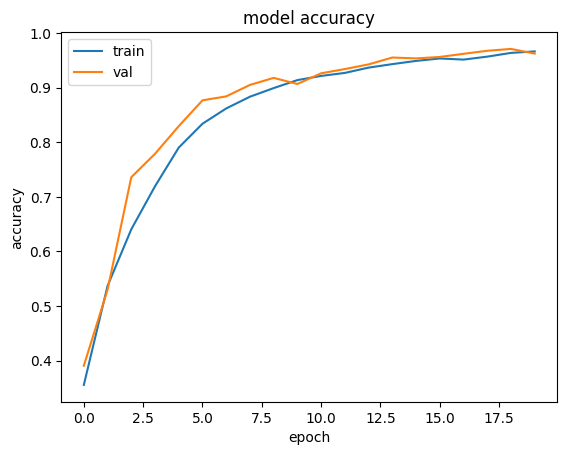

In [ ]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

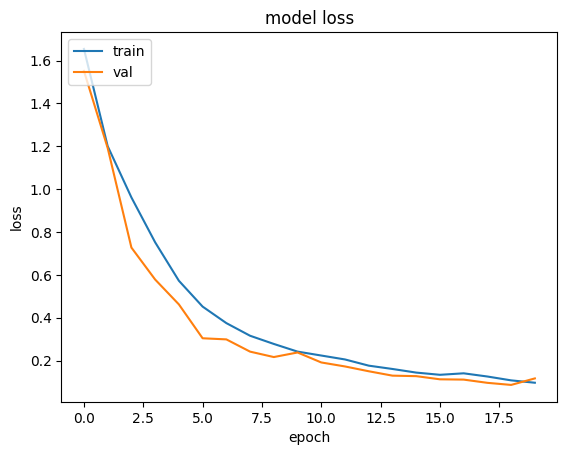

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Model Training

In [ ]:
# Print the number of values returned by the evaluate method.
num_values = len(model.evaluate(X_test, Y_test, verbose=1))
print(num_values)

294/294 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - acc: 0.9641 - auc: 0.9971 - false_negatives: 179.0610 - false_positives: 158.3186 - loss: 0.1178 - precision: 0.9661 - recall: 0.9622 - true_negatives: 28256.1758 - true_positives: 4556.6880
9


# For Transfer Learning

In [ ]:
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications.resnet_v2 import ResNet152V2

from tensorflow.keras.applications.efficientnet import EfficientNetB7

In [ ]:
X_train_pad= np.pad(X_train,((0,0),(2,2),(2,2),(0,0)),'mean')

In [ ]:
X_test_pad= np.pad(X_test,((0,0),(2,2),(2,2),(0,0)),'mean')

In [ ]:
img_shape =(32,32,3)

Name= "ResNet"
classifier = ResNet152V2(
            include_top = False,input_shape=img_shape,
             weights='imagenet'
           )
fine_tune_at = 555
for layer in classifier.layers[:fine_tune_at]:
    layer.trainable = False
"""
# uncomment here
Name= "EfficientNetB7"
classifier = EfficientNetB7(
            include_top = False,input_shape=img_shape,
             weights='imagenet'
           )
fine_tune_at = 790
for layer in classifier.layers[:fine_tune_at]:
    layer.trainable = False

# uncomment here
Name= "VGG19"
classifier = VGG19(
            include_top = False,input_shape=img_shape,
             weights='imagenet'
           )

fine_tune_at = 20
for layer in classifier.layers[:fine_tune_at]:
    layer.trainable = False
"""
model = Sequential()
model.add(classifier)
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))
print(model.summary())

234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet152v2 (Functional)        │ (None, 1, 1, 2048)     │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,603,527 (223.55 MB)

 Trainable params: 3,682,567 (14.05 MB)

 Non-trainable params: 54,920,960 (209.51 MB)

None


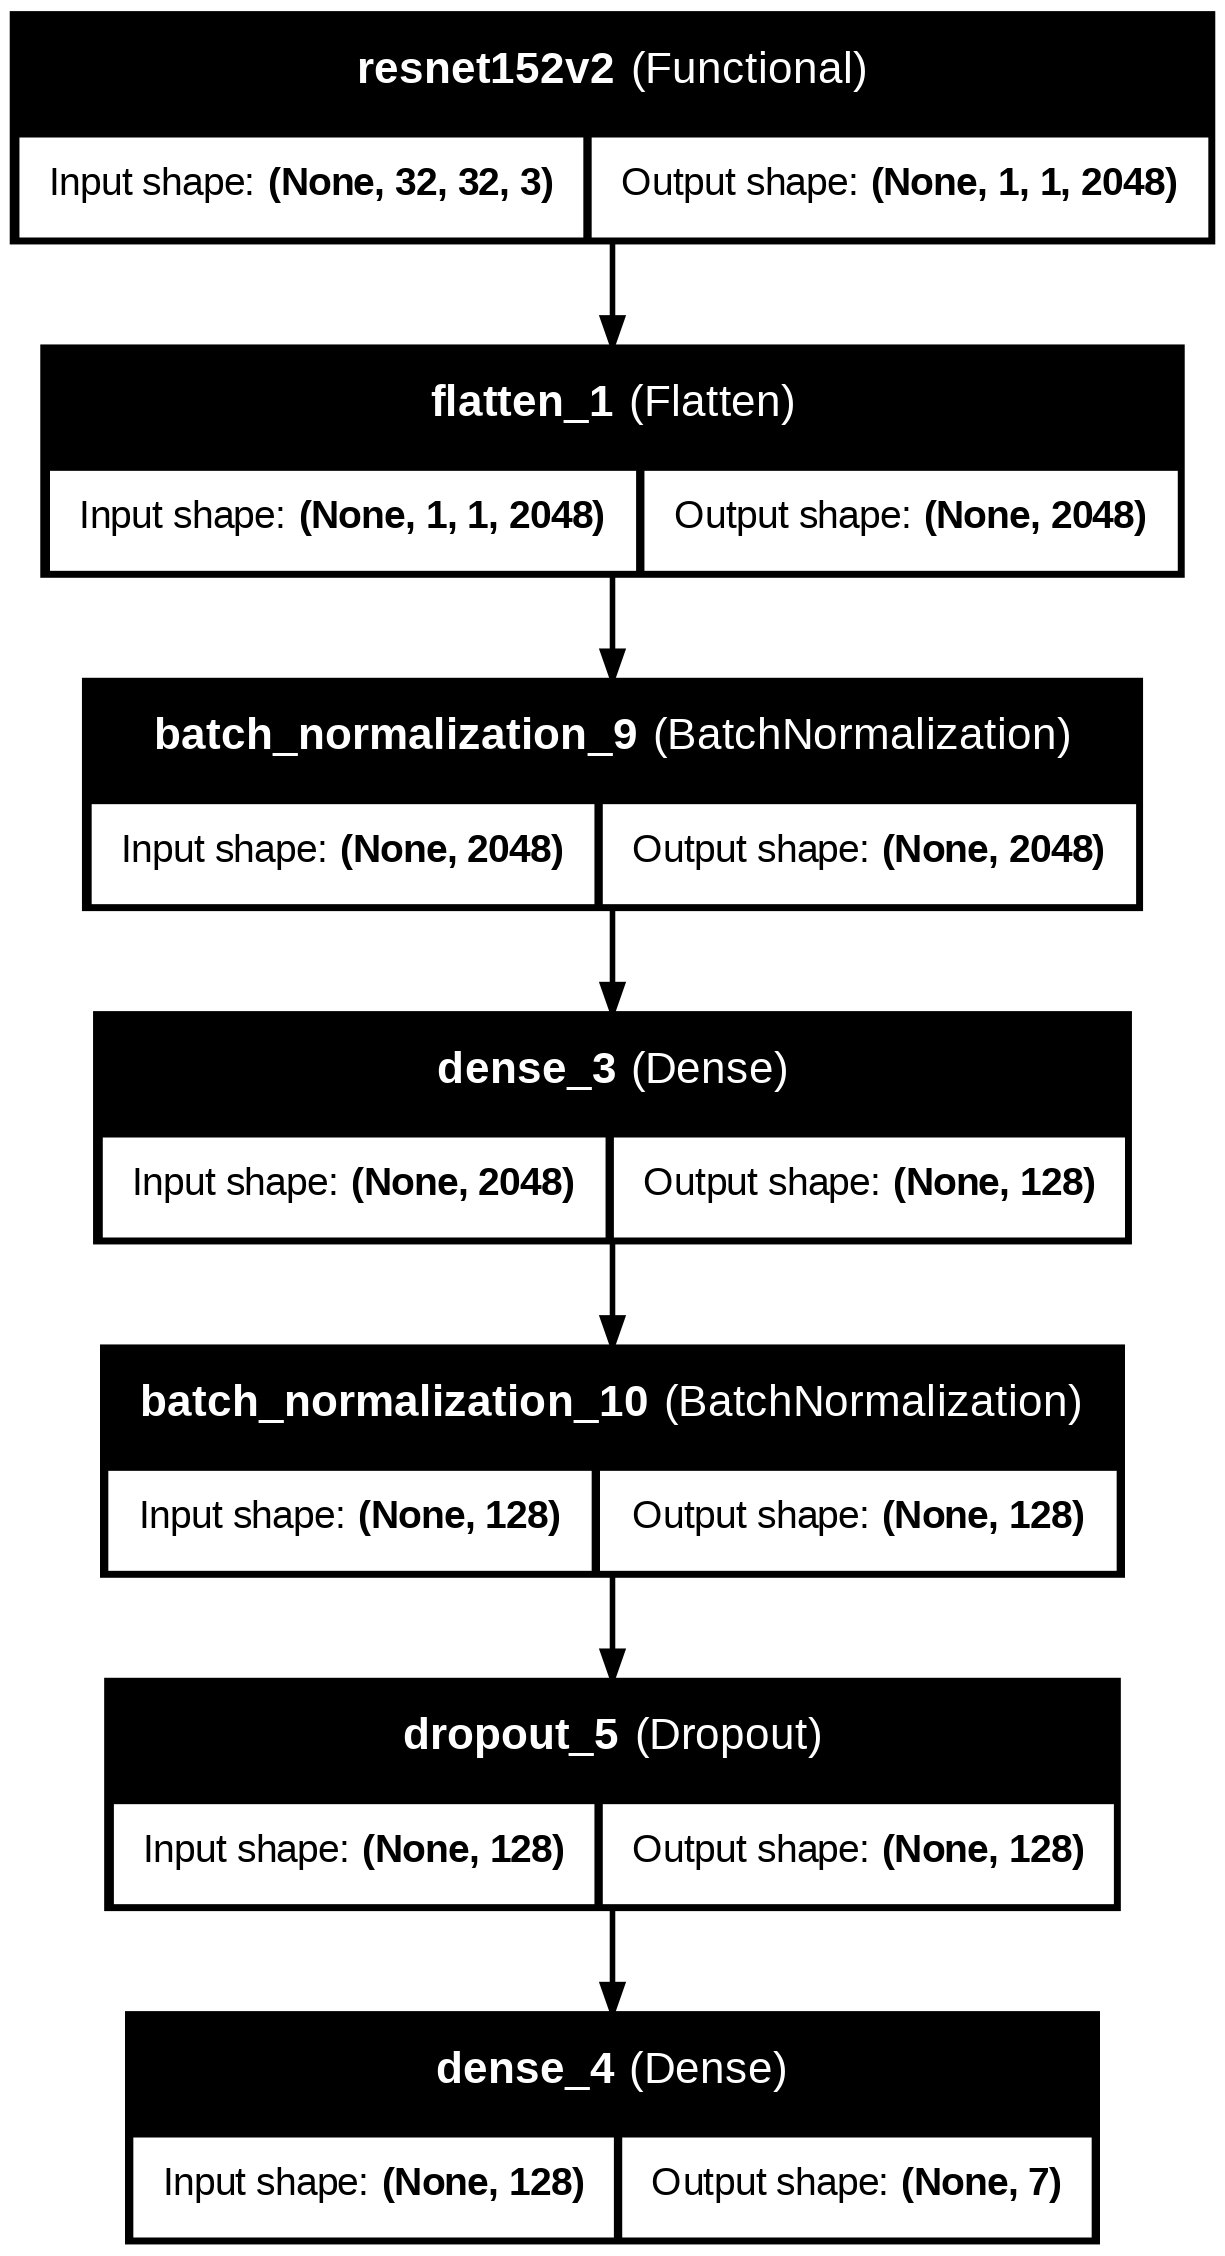

In [ ]:
plot_model(model, to_file=Name+'.png',show_shapes= True , show_layer_names=True)

In [ ]:
callback = tf.keras.callbacks.ModelCheckpoint(filepath='best_Resnet.h5',
                                                  monitor='val_acc', mode='max',
                                                 verbose=1)
model.compile(optimizer= keras.optimizers.Adam(),
              loss=keras.losses.CategoricalCrossentropy() ,
              metrics=['acc',Recall(),Precision(),AUC(),TruePositives(),TrueNegatives(),FalseNegatives(),FalsePositives()])
history = model.fit(X_train_pad, Y_train, epochs=20, validation_data=(X_test_pad, Y_test), batch_size=128, callbacks=[callback])

Epoch 1/20
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - acc: 0.5068 - auc_1: 0.8224 - false_negatives_1: 10708.1289 - false_positives_1: 3468.5000 - loss: 1.5312 - precision_1: 0.6316 - recall_1: 0.3648 - true_negatives_1: 109809.7891 - true_positives_1: 8171.5850
Epoch 1: saving model to best_Resnet.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 86s 182ms/step - acc: 0.5072 - auc_1: 0.8227 - false_negatives_1: 10732.4102 - false_positives_1: 3478.5151 - loss: 1.5297 - precision_1: 0.6320 - recall_1: 0.3654 - true_negatives_1: 110179.4609 - true_positives_1: 8210.5869 - val_acc: 0.7482 - val_auc_1: 0.9578 - val_false_negatives_1: 3583.0000 - val_false_positives_1: 934.0000 - val_loss: 0.7204 - val_precision_1: 0.8614 - val_recall_1: 0.6183 - val_true_negatives_1: 55388.0000 - val_true_positives_1: 5804.0000
Epoch 2/20
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.8125 - auc_1: 0.9753 - false_negatives_1: 4361.0479 - false_positives_1: 2174.5850 - loss: 0.5308 - precision_1: 0.8660 - recall_1: 0.7582 - true_negatives_1: 111103.7031 - true_positives_1: 14518.6670
Epoch 2: saving model to best_Resnet.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 36s 63ms/step - acc: 0.8125 - auc_1: 0.9753 - false_negatives_1: 4373.3965 - false_positives_1: 2181.3152 - loss: 0.5306 - precision_1: 0.8661 - recall_1: 0.7583 - true_negatives_1: 111476.6641 - true_positives_1: 14569.5996 - val_acc: 0.8418 - val_auc_1: 0.9738 - val_false_negatives_1: 1888.0000 - val_false_positives_1: 1043.0000 - val_loss: 0.5354 - val_precision_1: 0.8779 - val_recall_1: 0.7989 - val_true_negatives_1: 55279.0000 - val_true_positives_1: 7499.0000
Epoch 3/20
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - acc: 0.8849 - auc_1: 0.9907 - false_negatives_1: 2546.9695 - false_positives_1: 1529.3300 - loss: 0.3202 - precision_1: 0.9126 - recall_1: 0.8605 - true_negatives_1: 111748.9531 - true_positives_1: 16332.7451
Epoch 3: saving model to best_Resnet.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - acc: 0.8850 - auc_1: 0.9907 - false_negatives_1: 2554.8542 - false_positives_1: 1534.2407 - loss: 0.3201 - precision_1: 0.9126 - recall_1: 0.8606 - true_negatives_1: 112123.7422 - true_positives_1: 16388.1426 - val_acc: 0.8959 - val_auc_1: 0.9923 - val_false_negatives_1: 1163.0000 - val_false_positives_1: 767.0000 - val_loss: 0.2821 - val_precision_1: 0.9147 - val_recall_1: 0.8761 - val_true_negatives_1: 55555.0000 - val_true_positives_1: 8224.0000
Epoch 4/20
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - acc: 0.9145 - auc_1: 0.9944 - false_negatives_1: 1905.8430 - false_positives_1: 1213.9489 - loss: 0.2404 - precision_1: 0.9330 - recall_1: 0.8972 - true_negatives_1: 111682.0547 - true_positives_1: 16910.1562
Epoch 4: saving model to best_Resnet.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - acc: 0.9145 - auc_1: 0.9944 - false_negatives_1: 1917.6814 - false_positives_1: 1222.0034 - loss: 0.2404 - precision_1: 0.9330 - recall_1: 0.8972 - true_negatives_1: 112435.9766 - true_positives_1: 17025.3145 - val_acc: 0.9208 - val_auc_1: 0.9940 - val_false_negatives_1: 799.0000 - val_false_positives_1: 623.0000 - val_loss: 0.2314 - val_precision_1: 0.9324 - val_recall_1: 0.9149 - val_true_negatives_1: 55699.0000 - val_true_positives_1: 8588.0000
Epoch 5/20
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - acc: 0.9321 - auc_1: 0.9963 - false_negatives_1: 1444.3538 - false_positives_1: 1011.7109 - loss: 0.1904 - precision_1: 0.9439 - recall_1: 0.9219 - true_negatives_1: 112266.5781 - true_positives_1: 17435.3613
Epoch 5: saving model to best_Resnet.h5


...

294/294 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - acc: 0.9802 - auc_1: 0.9993 - false_negatives_1: 397.1763 - false_positives_1: 326.2542 - loss: 0.0584 - precision_1: 0.9821 - recall_1: 0.9783 - true_negatives_1: 113331.7266 - true_positives_1: 18545.8203 - val_acc: 0.9612 - val_auc_1: 0.9936 - val_false_negatives_1: 371.0000 - val_false_positives_1: 349.0000 - val_loss: 0.1599 - val_precision_1: 0.9627 - val_recall_1: 0.9605 - val_true_negatives_1: 55973.0000 - val_true_positives_1: 9016.0000
Epoch 17/20
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - acc: 0.9824 - auc_1: 0.9994 - false_negatives_1: 358.4744 - false_positives_1: 299.4676 - loss: 0.0522 - precision_1: 0.9843 - recall_1: 0.9812 - true_negatives_1: 112596.5312 - true_positives_1: 18457.5254
Epoch 17: saving model to best_Resnet.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 23s 79ms/step - acc: 0.9824 - auc_1: 0.9994 - false_negatives_1: 360.7627 - false_positives_1: 301.4102 - loss: 0.0521 - precision_1: 0.9843 - recall_1: 0.9812 - true_negatives_1: 113356.5703 - true_positives_1: 18582.2344 - val_acc: 0.9664 - val_auc_1: 0.9962 - val_false_negatives_1: 318.0000 - val_false_positives_1: 305.0000 - val_loss: 0.1211 - val_precision_1: 0.9675 - val_recall_1: 0.9661 - val_true_negatives_1: 56017.0000 - val_true_positives_1: 9069.0000
Epoch 18/20
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - acc: 0.9839 - auc_1: 0.9994 - false_negatives_1: 326.3515 - false_positives_1: 286.9249 - loss: 0.0485 - precision_1: 0.9850 - recall_1: 0.9830 - true_negatives_1: 112609.0781 - true_positives_1: 18489.6484
Epoch 18: saving model to best_Resnet.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - acc: 0.9839 - auc_1: 0.9994 - false_negatives_1: 329.0068 - false_positives_1: 289.2169 - loss: 0.0485 - precision_1: 0.9850 - recall_1: 0.9830 - true_negatives_1: 113368.7656 - true_positives_1: 18613.9902 - val_acc: 0.9563 - val_auc_1: 0.9946 - val_false_negatives_1: 430.0000 - val_false_positives_1: 388.0000 - val_loss: 0.1620 - val_precision_1: 0.9585 - val_recall_1: 0.9542 - val_true_negatives_1: 55934.0000 - val_true_positives_1: 8957.0000
Epoch 19/20
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9761 - auc_1: 0.9990 - false_negatives_1: 477.5905 - false_positives_1: 391.5495 - loss: 0.0714 - precision_1: 0.9785 - recall_1: 0.9735 - true_negatives_1: 112504.4531 - true_positives_1: 18338.4102
Epoch 19: saving model to best_Resnet.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 39s 79ms/step - acc: 0.9761 - auc_1: 0.9990 - false_negatives_1: 480.4068 - false_positives_1: 393.9254 - loss: 0.0714 - precision_1: 0.9785 - recall_1: 0.9735 - true_negatives_1: 113264.0547 - true_positives_1: 18462.5898 - val_acc: 0.9687 - val_auc_1: 0.9958 - val_false_negatives_1: 304.0000 - val_false_positives_1: 284.0000 - val_loss: 0.1248 - val_precision_1: 0.9697 - val_recall_1: 0.9676 - val_true_negatives_1: 56038.0000 - val_true_positives_1: 9083.0000
Epoch 20/20
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - acc: 0.9811 - auc_1: 0.9991 - false_negatives_1: 391.3891 - false_positives_1: 331.3652 - loss: 0.0559 - precision_1: 0.9831 - recall_1: 0.9800 - true_negatives_1: 112564.6328 - true_positives_1: 18424.6113
Epoch 20: saving model to best_Resnet.h5


294/294 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - acc: 0.9811 - auc_1: 0.9991 - false_negatives_1: 393.9559 - false_positives_1: 333.5322 - loss: 0.0559 - precision_1: 0.9831 - recall_1: 0.9800 - true_negatives_1: 113324.4453 - true_positives_1: 18549.0410 - val_acc: 0.9626 - val_auc_1: 0.9944 - val_false_negatives_1: 363.0000 - val_false_positives_1: 334.0000 - val_loss: 0.1569 - val_precision_1: 0.9643 - val_recall_1: 0.9613 - val_true_negatives_1: 55988.0000 - val_true_positives_1: 9024.0000


In [ ]:
model.save(Name+'.h5')

pd.DataFrame.from_dict(history.history).to_csv(Name+'.csv',index=False)

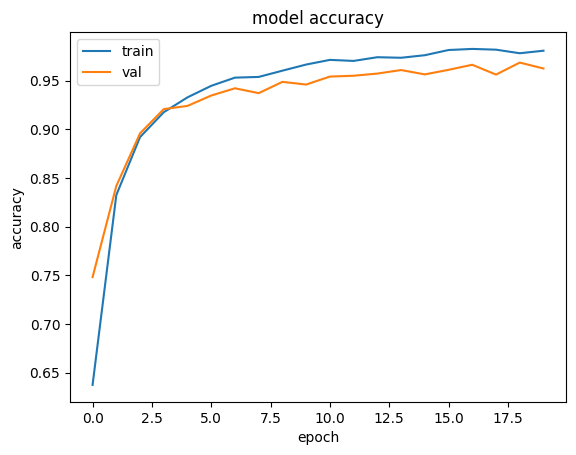

In [ ]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()